<a href="https://colab.research.google.com/github/crreyes-unal/Reporte-problemas-MpAM/blob/main/Ejercicio7_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***¿Cuál es el conjunto hipótesis del modelo de aprendizaje K Nearest Neighbours? ¿Cuál es su algoritmo de aprendizaje?***

Se parte de que $k$-NN es un modelo no paramétrico.

El conjunto de hipótesis $\mathcal{H}$ en $k$-NN corresponde a la clase de todas las funciones constantes a trozos definidas sobre una partición del espacio de características $\mathcal{X}$.

Dado un espacio métrico $(\mathcal{X}, d)$ y un conjunto de entrenamiento $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N \subset \mathcal{X} \times \mathcal{Y}$, la hipótesis $h \in \mathcal{H}$ elegida implícitamente por $k$-NN viene dada por

$$h(\mathbf{x}) = \arg\max_{c \in \mathcal{Y}} \sum_{i \in N_k(\mathbf{x}, \mathcal{D})} \mathbb{I}(y_i = c)$$

Donde $d(\cdot, \cdot)$ es una métrica de distancia, usualmente la euclidiana $\|\mathbf{x} - \mathbf{y}\|_2$. $N_k(\mathbf{x}, \mathcal{D})$ representa el conjunto de los $k$ índices correspondientes a los puntos de $\mathcal{D}$ más cercanos a $\mathbf{x}$ bajo $d$ y donde $\mathbb{I}(\cdot)$ es la función indicadora.

Ahora, se describe el algoritmo de aprendizaje.

$k$-NN pertenece a la familia de algoritmos de lazy learning basado en instancias. Se presentan dos fases, a saber, de entrenamiento y de inferencia.

*Fase 1: Entrenamiento*

* Entrada: Dataset $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$ y número de vecinos $k$.
* Proceso: Se memoriza el dataset $\mathcal{D}$ en memoria. Tambien, de forma opcional, se construyen estructuras de datos espaciales para optimizar búsquedas subsecuentes.
* Complejidad: $\mathcal{O}(1)$ en su versión básica. $\mathcal{O}(N \cdot d \log N)$ si se construye un árbol espacial.

*Fase 2: Inferencia*

Dada una nueva consulta $\mathbf{x}_{test} \in \mathcal{X}$:

* Cálculo de distancias: Computar $d(\mathbf{x}_{test}, \mathbf{x}_i)$ para todo $i \in \{1, \dots, N\}$.
* Elección del vecindario: Ordenar las distancias y seleccionar los $k$ puntos con menor valor de distancia para formar el conjunto $N_k(\mathbf{x}_{test}, \mathcal{D})$.
* Promedio:
   * Clasificación: Asignar la clase con mayor frecuencia relativa en el vecindario $N_k$.
   * Regresión: Calcular la media o mediana de la variable de respuesta $y$ entre los $k$ vecinos.

Ahora se presenta un ejemplo ilustrativo de la implementación de kNN

In [7]:
import numpy as np

class KNearestNeighbors:
    """
    Implementación en numpy K-NN.
    """
    def __init__(self, k: int = 3, metric: str = 'euclidean'):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Fase de entrenamiento
        """
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)

    def _compute_distances(self, X_test: np.ndarray) -> np.ndarray:
        """
        Calcula la matriz de distancias euclidianas
        """
        if self.metric == 'euclidean':
            # ||a - b||^2 = ||a||^2 + ||b||^2 - 2<a, b>
            distances = np.sqrt(
                np.sum(X_test**2, axis=1, keepdims=True) +
                np.sum(self.X_train**2, axis=1) -
                2 * np.dot(X_test, self.X_train.T)
            )
            return np.maximum(distances, 0.0)
        else:
            raise ValueError(f"Métrica '{self.metric}' no soportada.")

    def predict(self, X_test: np.ndarray) -> np.ndarray:
        """
        Fase de inferencia
        """
        X_test = np.asarray(X_test)
        distances = self._compute_distances(X_test)

        predictions = []
        for row in distances:

            # Obtener los índices de los k vecinos con menor distancia
            k_neighbor_indices = np.argsort(row)[:self.k]
            k_neighbor_labels = self.y_train[k_neighbor_indices]

            # Para el promedio
            labels, counts = np.unique(k_neighbor_labels, return_counts=True)
            most_common = labels[np.argmax(counts)]
            predictions.append(most_common)

        return np.array(predictions)


# Ejemplo
if __name__ == "__main__":
    # Dataset de ejemplo
    X_dummy = np.array([
        # Clase 0 tomada alrededor de x=1.0, y=1.0
        [0.8, 0.9], [1.0, 1.1], [0.9, 1.2], [1.1, 0.8], [1.2, 1.0], [0.9, 0.9],
        # Clase 1 tomada alrededor de x=1.3, y=1.3
        [1.2, 1.3], [1.4, 1.1], [1.3, 1.5], [1.5, 1.2], [1.4, 1.4], [1.3, 1.1]
    ])
    y_dummy = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

    clf = KNearestNeighbors(k=3)
    clf.fit(X_dummy, y_dummy)

    # Puntos de consulta evaluados cerca del límite
    X_query = np.array([
        [0.95, 1.05],
        [1.15, 1.15],
        [1.35, 1.25],
        [1.25, 1.35]
    ])
    preds = clf.predict(X_query)

    print(f"Las predicciones para los puntos de consulta son: {preds}")

Predicciones para los puntos de consulta: [0 0 1 1]


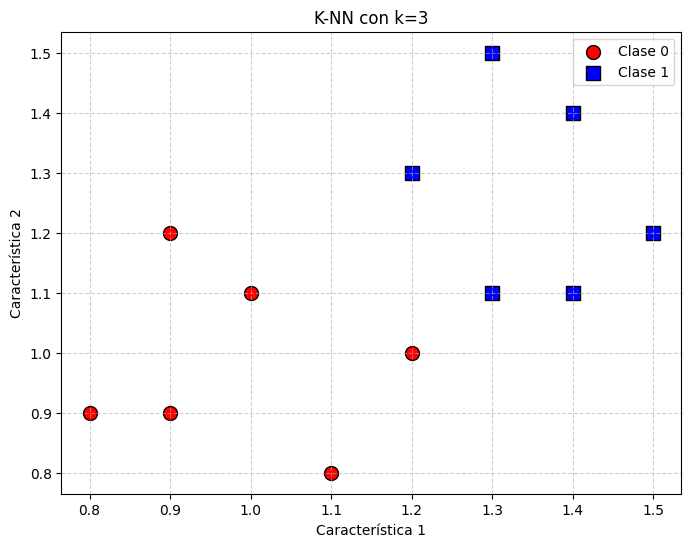

In [10]:
import matplotlib.pyplot as plt

# Crear la figura
plt.figure(figsize=(8, 6))

# Graficar los puntos de entrenamiento separados por clase
plt.scatter(X_dummy[y_dummy == 0][:, 0], X_dummy[y_dummy == 0][:, 1],
            color='red', label='Clase 0', marker='o', s=100, edgecolor='k')
plt.scatter(X_dummy[y_dummy == 1][:, 0], X_dummy[y_dummy == 1][:, 1],
            color='blue', label='Clase 1', marker='s', s=100, edgecolor='k')

# Graficar los puntos de consulta
for i, x_q in enumerate(X_query):
    # Usar rojo para 0 y azul para 1
    color_pred = 'red' if preds[i] == 0 else 'blue'

# Nombres del gráfico
plt.title('K-NN con k=3')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()